In [1]:
import xarray as xr
import xesmf as xe
import numpy as np

#### Overview

This notebook uses the 0.1 deg x 0.1 deg landsea mask from IMERG to calculate land masks for models without land fraction files available, including:
* GFDL-SPEAR-MED
* HiRAM-SIT-HR
* HiRAM-SIT-LR
* MPI-ESM1-2-XR

Conservative regridding is used to perform regridding of land fraction. 

In [2]:
imerg_landmask = xr.open_dataset("../input_data/IMERG_land_sea_mask.nc").sel(lon = slice(0, 360))

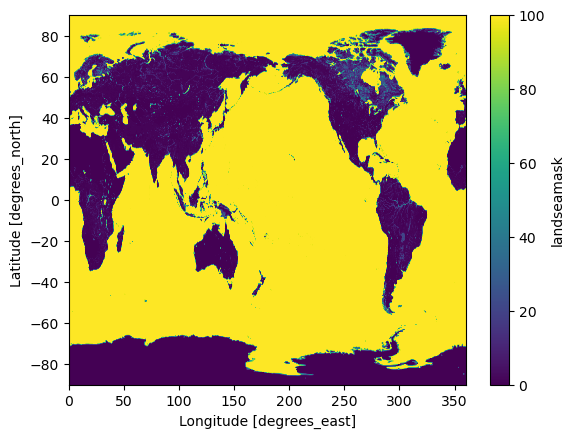

In [3]:
imerg_landmask.landseamask.plot()

In [4]:
imerg_grid = xr.Dataset({'lon': imerg_landmask.lon,
                           'lat': imerg_landmask.lat, 
                         'lon_b': np.linspace(0, 360, 3601), 
                           'lat_b': np.linspace(-90, 90, 1801),
                          })

#### Regrid to SPEAR grid

In [5]:
spear = xr.open_dataset("/davenport-scratch/DATA/GFDL-SPEAR/GFDL-SPEAR-MED/historical/r1i1p1f1/fx/areacella/gr3/v20210201/areacella_fx_GFDL-SPEAR-MED_historical_r1i1p1f1_gr3.nc")

In [6]:
spear

<xarray.Dataset> Size: 852kB
Dimensions:    (lat: 360, lon: 576, bnds: 2)
Coordinates:
  * bnds       (bnds) float64 16B 1.0 2.0
  * lat        (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon        (lon) float64 5kB 0.3125 0.9375 1.562 2.188 ... 358.4 359.1 359.7
Data variables:
    areacella  (lat, lon) float32 829kB ...
    lat_bnds   (lat, bnds) float64 6kB ...
    lon_bnds   (lon, bnds) float64 9kB ...
Attributes: (12/27)
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               fx
    contact:                gfdl.climate.model.info@noaa.gov
    experiment:             all-forcing simulation for 1921 to 2014
    experiment_id:          historical
    Conventions:            CF-1.7
    ...                     ...
    tracking_id:            55a402da-a2f4-43b9-8fb8-641c9dbb5715
    references:             SPEAR: The next generation GFDL modeling system f...
    title:                  NOAA GFDL GFDL-SPEAR-MED, all-forcing simulation ...
    gfdl_experiment_name:   SPEAR-MED.historical.r1
    license:                CC-BY-SA-4.0
    forcing:                CMIP6 historical

In [7]:
spear_grid = xr.Dataset({'lon': spear.lon,
                           'lat': spear.lat, 
                         'lon_b': np.linspace(0, 360, 577), 
                           'lat_b': np.linspace(-90, 90, 361),
                          })

In [8]:
spear_regridder = xe.Regridder(imerg_grid, spear_grid, method='conservative', periodic=True)

In [9]:
spear_landmask = spear_regridder(imerg_landmask)

In [10]:
spear_landmask

<xarray.Dataset> Size: 837kB
Dimensions:      (lat: 360, lon: 576)
Coordinates:
  * lon          (lon) float64 5kB 0.3125 0.9375 1.562 ... 358.4 359.1 359.7
  * lat          (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Data variables:
    landseamask  (lat, lon) float32 829kB 0.0 0.0 0.0 0.0 ... 100.0 100.0 100.0
Attributes:
    regrid_method:  conservative

In [11]:
spear_landmask["landseamask"] = 100 - spear_landmask.landseamask

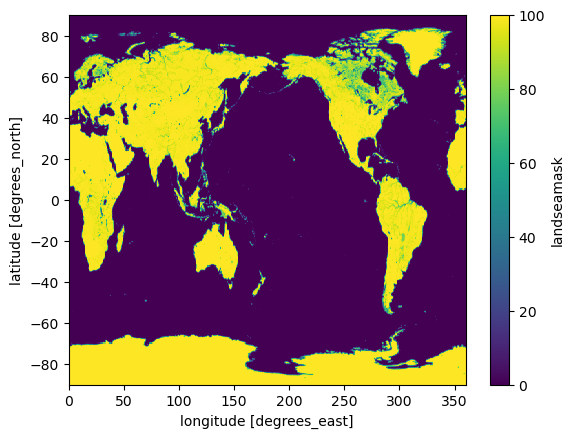

In [12]:
spear_landmask.landseamask.plot()

In [13]:
spear_landmask.to_netcdf("../processed_data/landmasks/GFDL-SPEAR-MED_landmask.nc")

#### Regrid to HiRAM-SIT-HR grid

In [14]:
hiram_hr = xr.open_dataset("/davenport-scratch/DATA/CMIP6/raw_data/hist-1950/mon/pr/pr_Amon_HiRAM-SIT-HR_hist-1950_r1i1p1f1_gn_195001-195012.nc")

In [15]:
hiram_hr

<xarray.Dataset> Size: 57MB
Dimensions:    (time: 12, bnds: 2, lat: 768, lon: 1536)
Coordinates:
  * time       (time) datetime64[ns] 96B 1950-01-16T12:00:00 ... 1950-12-16T1...
  * lat        (lat) float64 6kB -89.88 -89.65 -89.41 ... 89.41 89.65 89.88
  * lon        (lon) float64 12kB 0.1172 0.3516 0.5859 ... 359.4 359.6 359.9
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 192B ...
    lat_bnds   (lat, bnds) float64 12kB ...
    lon_bnds   (lon, bnds) float64 25kB ...
    pr         (time, lat, lon) float32 57MB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            HighResMIP
    branch_method:          no parent
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                Dr. Chia-Ying Tu (cytu@gate.sinica.edu.tw)
    ...                     ...
    title:                  HiRAM-SIT-HR output prepared for CMIP6
    variable_id:            pr
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by REQUIRED is licensed...
    cmor_version:           3.5.0
    tracking_id:            hdl:21.14100/16420cee-e883-4ee2-bec5-837a3233956f

In [17]:
hiram_hr_grid = xr.Dataset({'lon': hiram_hr.lon,
                           'lat': hiram_hr.lat, 
                         'lon_b': np.linspace(0, 360, 1537), 
                           'lat_b': np.linspace(-90, 90, 769),
                          })

hiram_hr_regridder = xe.Regridder(imerg_grid, hiram_hr_grid, method='conservative', periodic=True)
hiram_hr_landmask = hiram_hr_regridder(imerg_landmask)

In [18]:
hiram_hr_landmask["landseamask"] = 100 - hiram_hr_landmask.landseamask

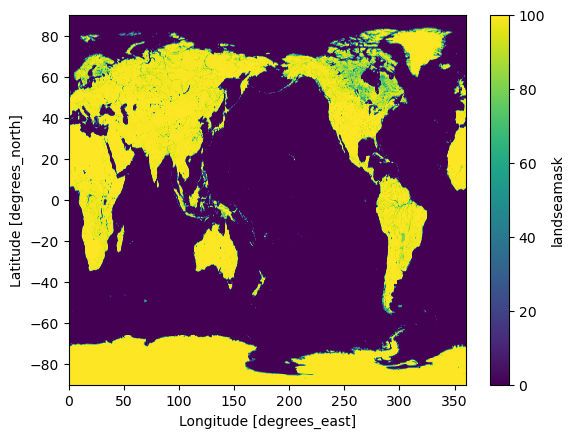

In [19]:
hiram_hr_landmask.landseamask.plot()

In [20]:
hiram_hr_landmask.to_netcdf("../processed_data/landmasks/HiRAM-SIT-HR_landmask.nc")

#### Regrid HiRAM-SIT-LR

In [21]:
hiram_lr = xr.open_dataset("/davenport-scratch/DATA/CMIP6/raw_data/hist-1950/mon/pr/pr_Amon_HiRAM-SIT-LR_hist-1950_r1i1p1f1_gn_195001-195012.nc")

In [22]:
hiram_lr

<xarray.Dataset> Size: 12MB
Dimensions:    (time: 12, bnds: 2, lat: 360, lon: 720)
Coordinates:
  * time       (time) datetime64[ns] 96B 1950-01-16T12:00:00 ... 1950-12-16T1...
  * lat        (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon        (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 192B ...
    lat_bnds   (lat, bnds) float64 6kB ...
    lon_bnds   (lon, bnds) float64 12kB ...
    pr         (time, lat, lon) float32 12MB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            HighResMIP
    branch_method:          no parent
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                Dr. Chia-Ying Tu (cytu@gate.sinica.edu.tw)
    ...                     ...
    title:                  HiRAM-SIT-LR output prepared for CMIP6
    variable_id:            pr
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by REQUIRED is licensed...
    cmor_version:           3.5.0
    tracking_id:            hdl:21.14100/3fcc37d8-e427-41bc-a0b7-8ecee7d6eb0f

In [23]:
hiram_lr_grid = xr.Dataset({'lon': hiram_lr.lon,
                           'lat': hiram_lr.lat, 
                         'lon_b': np.linspace(0, 360, 721), 
                           'lat_b': np.linspace(-90, 90, 361),
                          })

hiram_lr_regridder = xe.Regridder(imerg_grid, hiram_lr_grid, method='conservative', periodic=True)
hiram_lr_landmask = hiram_hr_regridder(imerg_landmask)

In [24]:
hiram_lr_landmask["landseamask"] = 100 - hiram_lr_landmask.landseamask

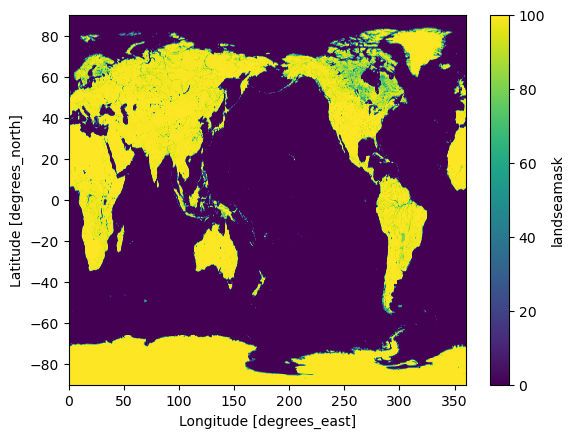

In [25]:
hiram_lr_landmask.landseamask.plot()

In [26]:
hiram_lr_landmask.to_netcdf("../processed_data/landmasks/HiRAM-SIT-LR_landmask.nc")

#### Regrid MPI-ESM1-2-XR

In [27]:
mpi_xr = xr.open_dataset("/davenport-scratch/DATA/CMIP6/raw_data/hist-1950/mon/pr/pr_Amon_MPI-ESM1-2-XR_hist-1950_r1i1p1f1_gn_195001-195012.nc")

In [28]:
mpi_xr

<xarray.Dataset> Size: 14MB
Dimensions:    (lon: 768, bnds: 2, lat: 384, time: 12)
Coordinates:
  * lon        (lon) float64 6kB 0.0 0.4688 0.9375 1.406 ... 358.6 359.1 359.5
  * lat        (lat) float64 3kB -89.64 -89.18 -88.71 ... 88.71 89.18 89.64
  * time       (time) datetime64[ns] 96B 1950-01-31T23:58:00 ... 1950-12-31T2...
Dimensions without coordinates: bnds
Data variables:
    lon_bnds   (lon, bnds) float64 12kB ...
    lat_bnds   (lat, bnds) float64 6kB ...
    time_bnds  (time, bnds) datetime64[ns] 192B ...
    pr         (time, lat, lon) float32 14MB ...
Attributes: (12/44)
    creation_date:              2018-05-25T07:42:08Z
    activity_id:                HighResMIP
    branch_time_in_child:       36524.0
    branch_time_in_parent:      45655.0
    branch_method:              fixed historical forcing from 1950 was applie...
    Conventions:                CF-1.7 CMIP-6.2
    ...                         ...
    data_specs_version:         01.00.23
    nco_openmp_thread_number:   1
    NCO:                        4.7.3
    history_of_appended_files:  Thu Nov 21 13:06:13 2019: Appended file /gws/...
    external_variables:         areacella
    history:                    Thu Nov 21 13:06:13 2019: ncks -A -v lat_bnds...

In [29]:
mpi_xr_grid = xr.Dataset({'lon': mpi_xr.lon,
                           'lat': mpi_xr.lat, 
                         'lon_b': np.linspace(0, 360, 769), 
                           'lat_b': np.linspace(-90, 90, 385),
                          })

mpi_xr_regridder = xe.Regridder(imerg_grid, mpi_xr_grid, method='conservative', periodic=True)
mpi_xr_landmask = mpi_xr_regridder(imerg_landmask)

In [30]:
mpi_xr_landmask["landseamask"] = 100 - mpi_xr_landmask.landseamask

In [31]:
mpi_xr_landmask.to_netcdf("../processed_data/landmasks/MPI-ESM1-2-XR_landmask.nc")

#### Regrid to CAS-ESM2-0

In [5]:
cas = xr.open_dataset("/davenport-scratch/DATA/CMIP6/raw_data/historical/mon/pr/pr_Amon_CAS-ESM2-0_historical_r1i1p1f1_gn_185001-201412.nc")

In [6]:
cas

<xarray.Dataset> Size: 260MB
Dimensions:    (time: 1980, bnds: 2, lat: 128, lon: 256)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 1kB -90.0 -88.58 -87.17 -85.75 ... 87.17 88.58 90.0
  * lon        (lon) float64 2kB 0.0 1.406 2.812 4.219 ... 355.8 357.2 358.6
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 32kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 4kB ...
    pr         (time, lat, lon) float32 260MB ...
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                Zhang He (zhanghe@mail.iap.ac.cn)
    ...                     ...
    title:                  CAS-ESM2-0 output prepared for CMIP6
    tracking_id:            hdl:21.14100/14781074-4117-4ae2-94eb-8576a9c20440
    variable_id:            pr
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by Institute of Atmosph...
    cmor_version:           3.5.0

In [7]:
cas_grid = xr.Dataset({'lon': cas.lon,
                           'lat': cas.lat, 
                         'lon_b': np.linspace(0, 360, 257), 
                           'lat_b': np.linspace(-90, 90, 129),
                          })

cas_regridder = xe.Regridder(imerg_grid, cas_grid, method='conservative', periodic=True)
cas_landmask = cas_regridder(imerg_landmask)

In [8]:
cas_landmask["landseamask"] = 100 - cas_landmask.landseamask

In [12]:
cas_landmask.to_netcdf("../processed_data/landmasks/CAS-ESM2-0_landmask.nc")

#### Regrid to IITM-ESM

In [16]:
iitm = xr.open_dataset("/davenport-scratch/DATA/CMIP6/raw_data/historical/mon/pr/pr_Amon_IITM-ESM_historical_r1i1p1f1_gn_185001-185912.nc")
iitm

<xarray.Dataset> Size: 9MB
Dimensions:    (time: 120, bnds: 2, lat: 94, lon: 192)
Coordinates:
  * time       (time) object 960B 1850-01-16 12:00:00 ... 1859-12-16 12:00:00
  * lat        (lat) float64 752B -88.54 -86.65 -84.75 ... 84.75 86.65 88.54
  * lon        (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 2kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    pr         (time, lat, lon) float32 9MB ...
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          Spin-up documentation
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                iitm-esm@tropmet.res.in
    ...                     ...
    title:                  IITM-ESM output prepared for CMIP6
    variable_id:            pr
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by CCCR-IITM is license...
    cmor_version:           3.5.0
    tracking_id:            hdl:21.14100/cdd330d3-060b-48c2-9aaa-79f2b56ada04

In [19]:
iitm_grid = xr.Dataset({'lon': iitm.lon,
                           'lat': iitm.lat, 
                         'lon_b': np.linspace(0, 360, 193), 
                           'lat_b': np.linspace(-90, 90, 95),
                          })

iitm_regridder = xe.Regridder(imerg_grid, iitm_grid, method='conservative', periodic=True)
iitm_landmask = iitm_regridder(imerg_landmask)
iitm_landmask["landseamask"] = 100 - iitm_landmask.landseamask

In [20]:
iitm_landmask.to_netcdf("../processed_data/landmasks/IITM-ESM_landmask.nc")

#### Regrid to KIOST-ESM

In [21]:
kiost = xr.open_dataset("/davenport-scratch/DATA/CMIP6/raw_data/historical/mon/pr/pr_Amon_KIOST-ESM_historical_r1i1p1f1_gr1_185001-201412.nc")
kiost

<xarray.Dataset> Size: 146MB
Dimensions:    (time: 1980, bnds: 2, lon: 192, lat: 96)
Coordinates:
  * time       (time) object 16kB 1850-01-17 12:00:00 ... 2014-12-17 12:00:00
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.563 ... 355.3 357.2 359.1
  * lat        (lat) float64 768B -89.06 -87.19 -85.31 ... 85.31 87.19 89.06
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 32kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    pr         (time, lat, lon) float32 146MB ...
Attributes: (12/49)
    CDI:                    Climate Data Interface version 1.9.7.1 (http://mp...
    history:                Tue Sep 28 13:56:50 2021: cdo mergetime /data/hkj...
    source:                 KIOST-ESM (2018): \naerosol: none\natmos: GFDL-AM...
    institution:            Korea Institute of Ocean Science & Technology, Bu...
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    ...                     ...
    tracking_id:            hdl:21.14100/47e8b15e-178e-49a9-a084-df4a44880f41
    variable_id:            pr
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by Lawrence Livermore K...
    cmor_version:           3.5.0
    CDO:                    Climate Data Operators version 1.9.7.1 (http://mp...

In [22]:
kiost_grid = xr.Dataset({'lon': kiost.lon,
                           'lat': kiost.lat, 
                         'lon_b': np.linspace(0, 360, 193), 
                           'lat_b': np.linspace(-90, 90, 97),
                          })

kiost_regridder = xe.Regridder(imerg_grid, kiost_grid, method='conservative', periodic=True)
kiost_landmask = kiost_regridder(imerg_landmask)
kiost_landmask["landseamask"] = 100 - kiost_landmask.landseamask

In [23]:
kiost_landmask.to_netcdf("../processed_data/landmasks/KIOST-ESM_landmask.nc")